In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

ps = PorterStemmer()

print(ps.stem('loving'))

love


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv('phishing_email.csv')

In [3]:
df.head(1)

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0


In [4]:
df.tail(1)

,text_combined,label
82485,fastway infofastwaycoza_infofastwaycoza_infofa...,1


In [5]:
df.shape

(82486, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [7]:
#renaming the columns
df.rename(columns={'text_combined':'text', 'label':'target'}, inplace = True)
df.head(5)

,text,target
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [8]:
#missing values
df.isnull().sum()

text      0
target    0
dtype: int64

In [9]:
#check for duplicate value
df.duplicated().sum()

np.int64(408)

In [10]:
#remove duplicated
df= df.drop_duplicates(keep = 'first')

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(82078, 2)

In [13]:
 df.head()

,text,target
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [14]:
df['target'].value_counts()

target
1    42845
0    39233
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x2614b7b17f0>,
 [Text(-0.0759779853362729, 1.0973729292014822, 'ham'),
  Text(0.07597768882052051, -1.0973729497310805, 'spam')],
 [Text(-0.04144253745614885, 0.5985670522917175, '52.20'),
  Text(0.04144237572028391, -0.5985670634896801, '47.80')])

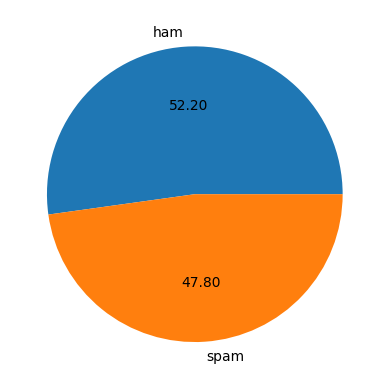

In [15]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct = "%0.2f")

In [16]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
df['num_characters'] = df['text'].apply(len)
df.head()

,text,target,num_characters
0,hpl nom may 25 2001 see attached file hplno 52...,0,65
1,nom actual vols 24 th forwarded sabrae zajac h...,0,1071
2,enron actuals march 30 april 1 201 estimated a...,0,148
3,hpl nom may 30 2001 see attached file hplno 53...,0,65
4,hpl nom june 1 2001 see attached file hplno 60...,0,65


In [18]:
# number of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

,text,target,num_characters,num_words
0,hpl nom may 25 2001 see attached file hplno 52...,0,65,14
1,nom actual vols 24 th forwarded sabrae zajac h...,0,1071,208
2,enron actuals march 30 april 1 201 estimated a...,0,148,28
3,hpl nom may 30 2001 see attached file hplno 53...,0,65,14
4,hpl nom june 1 2001 see attached file hplno 60...,0,65,14


In [19]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,text,target,num_characters,num_words,num_sentences
0,hpl nom may 25 2001 see attached file hplno 52...,0,65,14,1
1,nom actual vols 24 th forwarded sabrae zajac h...,0,1071,208,1
2,enron actuals march 30 april 1 201 estimated a...,0,148,28,1
3,hpl nom may 30 2001 see attached file hplno 53...,0,65,14,1
4,hpl nom june 1 2001 see attached file hplno 60...,0,65,14,1


In [20]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,8.207800e+04,82078.000000,82078.000000
mean,1.290496e+03,160.715003,0.999988
std,1.553506e+04,544.992481,0.003490
min,1.000000e+00,0.000000,0.000000
25%,2.760000e+02,39.000000,1.000000
50%,5.580000e+02,78.000000,1.000000
75%,1.339000e+03,183.000000,1.000000
max,4.279526e+06,107710.000000,1.000000


In [21]:
df[df['target'] == 0 ][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,39233.000000,39233.000000,39233.0
mean,1541.456147,203.703897,1.0
std,3711.537111,481.196373,0.0
min,11.000000,2.000000,1.0
25%,411.000000,57.000000,1.0
50%,780.000000,106.000000,1.0
75%,1495.000000,203.000000,1.0
max,160318.000000,23359.000000,1.0


In [22]:
df[df['target'] == 1 ][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4.284500e+04,42845.000000,42845.000000
mean,1.060693e+03,121.350239,0.999977
std,2.120404e+04,594.751582,0.004831
min,1.000000e+00,0.000000,0.000000
25%,2.410000e+02,32.000000,1.000000
50%,3.910000e+02,55.000000,1.000000
75%,1.058000e+03,154.000000,1.000000
max,4.279526e+06,107710.000000,1.000000


<Axes: xlabel='num_characters', ylabel='Count'>

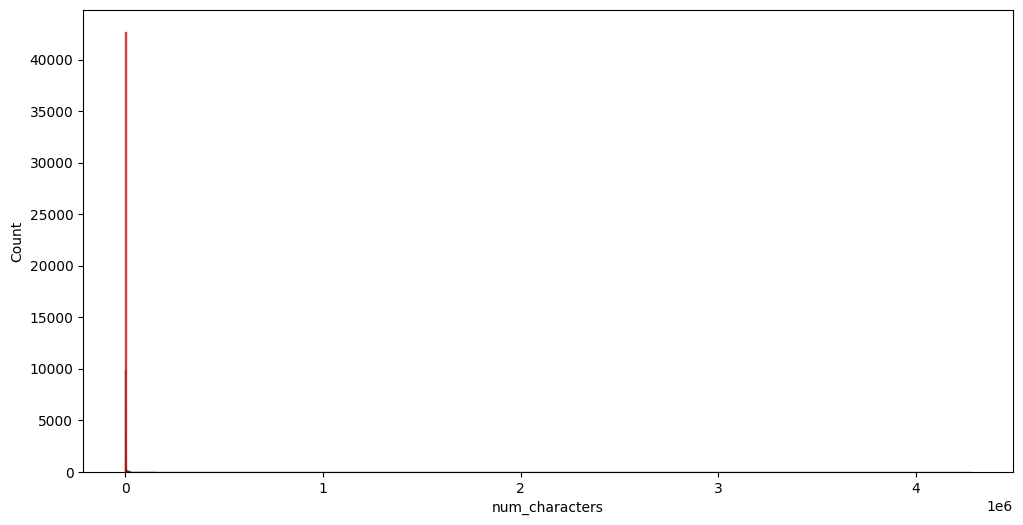

In [23]:
plt.figure(figsize = (12,6))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'], color = 'red')

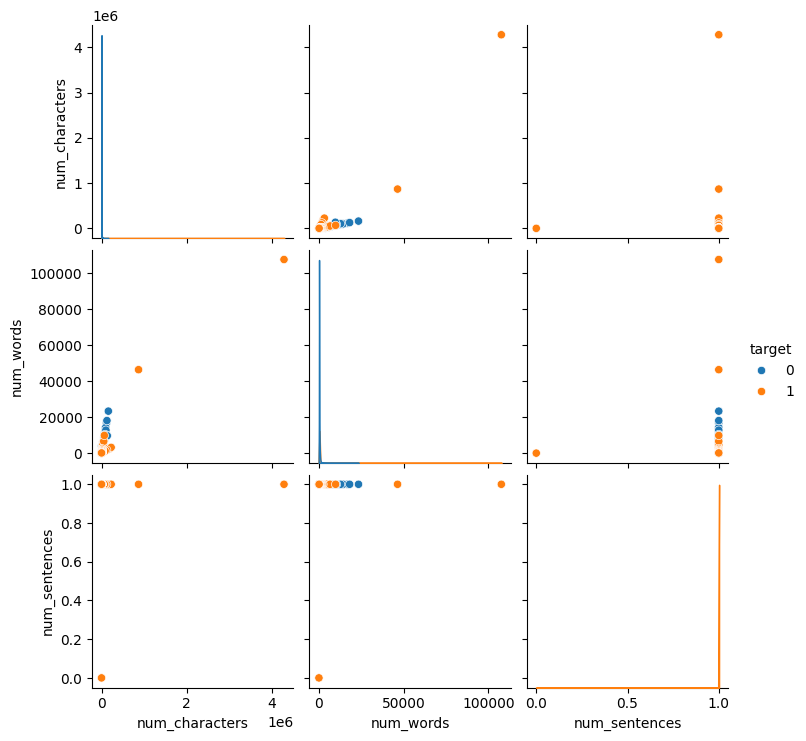

In [24]:
sns.pairplot(df, hue='target')

<Axes: >

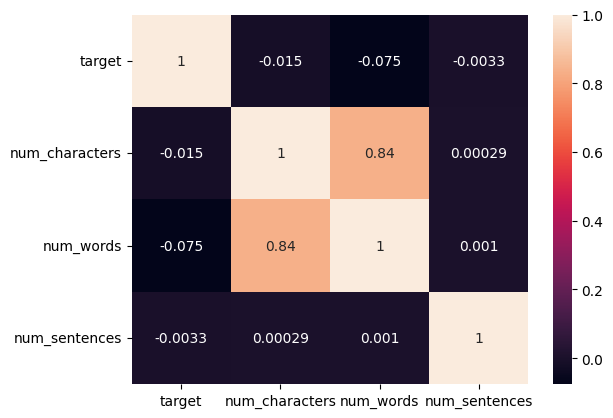

In [25]:
sns.heatmap(df[['target', 'num_characters', 'num_words', 'num_sentences']]  .corr(), annot = True)

In [26]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[: ] 
    y.clear()

    for i in text:
        y.append(ps.stem(i))
            
    return " ".join(y)

In [ ]:

df['transformed'] = df['text'].apply(transform_text)

In [ ]:
df.head()

In [35]:
from wordcloud import WordCloud
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')

In [36]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed'].str.cat(sep = " "))

ValueError: We need at least 1 word to plot a word cloud, got 0.

In [32]:
plt.imshow(spam_wc)

NameError: name 'spam_wc' is not defined

In [ ]:
spam_wc = wc.generate(df[df['target'] == 0]['transformed'].str.cat(sep = " "))
plt.imshow(spam_wc)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
tfidf = TfidfVectorizer()
cv = CountVectorizer()

In [ ]:
X = tfidf.fit_transform(df['transformed']).toarray()

In [ ]:
X.shape

In [ ]:
y = df['target'].values

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 2)

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

In [ ]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

In [ ]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)

knc = KNeighborsClassifier()

mnb = MultinomialNB()

dtc = DecisionTreeClassifier(max_depth=5)

lrc = LogisticRegression(solver='liblinear', penalty='l1')

rfc = RandomForestClassifier(n_estimators=50, random_state=2)

abc = AdaBoostClassifier(n_estimators=50, random_state=2)

bc = BaggingClassifier(n_estimators=50, random_state=2)

etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)

xgb = XGBClassifier(n_estimators=50, random_state=2)

In [ ]:
clfs = {
    'SVC': svc,
    'KNN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [ ]:


def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    return accuracy, precision

In [ ]:
train_classifier(svc, X_train, y_train, X_test, y_test)

In [ ]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    
    current_accuracy, current_precision = train_classifier(
        clf, X_train, y_train, X_test, y_test
    )

    print("For", name)
    print("Accuracy -", current_accuracy)
    print("Precision -", current_precision)
    print()

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)




In [ ]:
performance_df = pd.DataFrame({
    'Algorithm': list(clfs.keys()),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

performance_df

In [ ]:
performance_df

In [ ]:
performance_df1 = pd.melt(performance_df, id_vars = 'Algorithm')

In [ ]:
performance_df1